# Ridge Regression - Custom class
> #### <span style = 'color:orange; font-family:caveat'>for Univariate Dataset</span>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

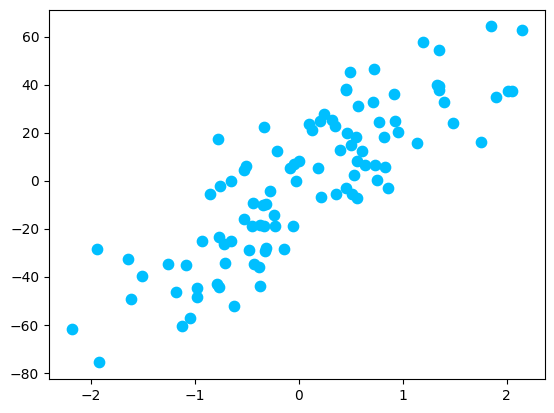

In [ ]:
# data generation
from sklearn.datasets import make_regression
x,y = make_regression(n_features=1, n_samples=100, n_informative=1, n_targets=1, noise = 20, random_state=13)

plt.scatter(x,y, color = 'deepskyblue', label = 'True data',s = 55)
plt.show()

In [7]:
# data split
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=2)

### Linear Regression

Intercept:  -2.2710144261783825
Coef:  [28.12597332]
R2 score:  0.6345158782661013


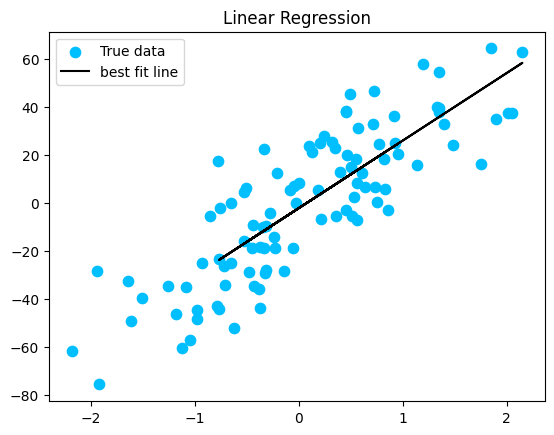

In [10]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)

print('Intercept: ',lr.intercept_)
print('Coef: ',lr.coef_)
print('R2 score: ',r2_score(y_test, y_pred_lr))


plt.scatter(x,y, color = 'deepskyblue', label = 'True data',s = 55)
plt.plot(x_test, y_pred_lr, color = 'k', label = 'best fit line')
plt.title('Linear Regression')
plt.legend()
plt.show()

### Ridge Regression

Intercept:  -2.104748900117316
Coef:  [24.84312743]
R2 score:  0.6387892505532382


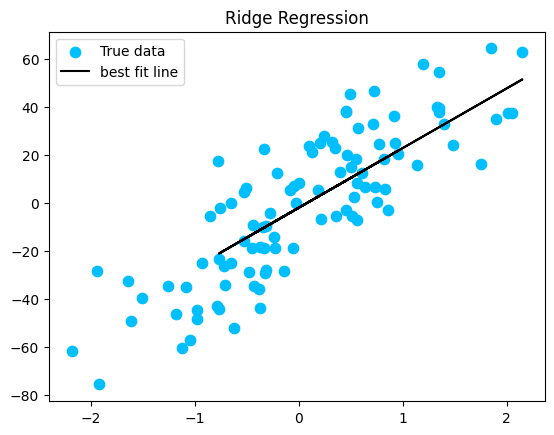

In [11]:
from sklearn.linear_model import Ridge
r = Ridge(alpha=10)
r.fit(x_train, y_train)
y_pred_r = r.predict(x_test)

print('Intercept: ',r.intercept_)
print('Coef: ',r.coef_)
print('R2 score: ',r2_score(y_test, y_pred_r))


plt.scatter(x,y, color = 'deepskyblue', label = 'True data',s = 55)
plt.plot(x_test, y_pred_r, color = 'k', label = 'best fit line')
plt.title('Ridge Regression')
plt.legend()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

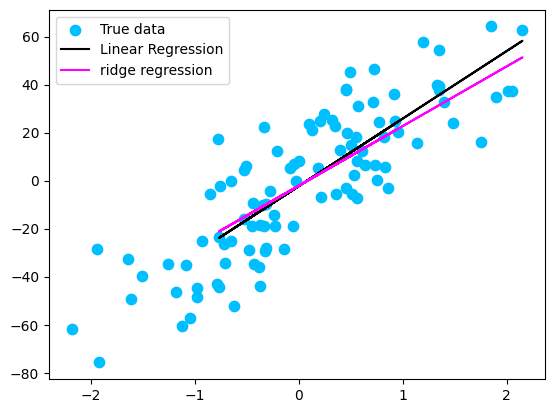

In [ ]:
plt.scatter(x,y, color = 'deepskyblue', label = 'True data',s = 55)
plt.plot(x_test, y_pred_lr, color = 'k', label = 'Linear Regression')
plt.plot(x_test, y_pred_r, color = 'magenta', label = 'Ridge Regression')
plt.legend()
plt.show

### Ridge Regression - Custom class
> 1 input | 1 output

In [13]:
class ridge_reg: 
    def __init__(self, alpha = 0.1):        # defaul value given for alpha
        self.m = None
        self.b = None
        self.alpha = alpha
    
    def fit(self, x_train, y_train):
        num = 0
        den = 0

        for i in range(x_train.shape[0]):
            num += ((x_train[i] - x_train.mean()) * (y_train[i] - y_train.mean()))
            den += ((x_train[i] - x_train.mean()) ** 2)
        
        self.m = num / (den + self.alpha)
        self.b = y_train.mean() - self.m * (x_train.mean())
        print('Slope: ',self.m)
        print('Intercept: ',self.b)
    
    def predict(self, x_test):
        return self.b + (self.m * x_test)

In [16]:
rr = ridge_reg(alpha = 10)
rr.fit(x_train, y_train)

y_pred_cc = rr.predict(x_test)
print('R2 Score: ',r2_score(y_test, y_pred_cc))

Slope:  [24.84312743]
Intercept:  [-2.1047489]
R2 Score:  0.6387892505532382
